# CNN with BatchNorm, GAP, Augmentation, and Weighted Loss

- Replaces the large flatten-based classifier with global average pooling
- Uses stronger training augmentation
- Trains longer with early stopping on validation F2

**Objective**
Test whether a smaller classifier head plus stronger augmentation improves generalization and reduces the early plateau seen in the previous weighted BatchNorm CNN experiment.


In [1]:
import sys
import os
import copy
import random

from pathlib import Path

# Find project root regardless of CWD (works in VS Code, Jupyter Lab, etc.)
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    fbeta_score,
    precision_score,
    recall_score,
)

from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.cnn_batchnorm_gap import BatchNormGAPCNN
from src.training.trainer import train_one_epoch, validate_one_epoch

os.chdir(ROOT)
print(Path.cwd())

/Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)

set_seed(42)

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: mps


In [4]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='data_new/splits/train.csv',
    val_csv='data_new/splits/val.csv',
    test_csv='data_new/splits/test.csv',
    image_dir='data_new/images/train',
    test_image_dir='data_new/images/test',
    batch_size=32,
    image_size=224,
    num_workers=0,
    transform_train=get_augmented_train_transforms(image_size=224),
)

train_df = pd.read_csv('data_new/splits/train.csv')

num_melanoma = (train_df['label'] == 1).sum()   # melanoma in CSV (label=1)
num_nevus = (train_df['label'] == 0).sum()      # nevus in CSV (label=0)

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='mps:0')


In [5]:
model = BatchNormGAPCNN().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

model_save_path = os.path.abspath("models/cnn_batchnorm_gap_augmented_weighted.pth")
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

num_epochs = 50
early_stopping_patience = 8

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_f2s = []
val_f2s = []
learning_rates = []

best_val_f2 = -1.0
best_epoch = -1
epochs_without_improvement = 0
best_model_state = None


In [6]:
for epoch in range(num_epochs):
    current_lr = optimizer.param_groups[0]["lr"]

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step(val_metrics["f2"])

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accuracies.append(train_metrics["accuracy"])
    val_accuracies.append(val_metrics["accuracy"])
    train_f2s.append(train_metrics["f2"])
    val_f2s.append(val_metrics["f2"])
    learning_rates.append(current_lr)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f}, Train F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}, Val F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics["f2"] > best_val_f2:
        best_val_f2 = val_metrics["f2"]
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, model_save_path)
        print(f"Saved best model at epoch {best_epoch}")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= early_stopping_patience:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

print(f"Best validation F2: {best_val_f2:.4f} at epoch {best_epoch}")

if best_model_state is not None:
    model.load_state_dict(best_model_state)


Epoch [1/50] | LR: 0.001000 | Train Loss: 1.1003, Train Acc: 0.5640, Train F2: 0.4538 | Val Loss: 1.4980, Val Acc: 0.7396, Val F2: 0.3424
Saved best model at epoch 1


Epoch [2/50] | LR: 0.001000 | Train Loss: 1.0297, Train Acc: 0.6147, Train F2: 0.4860 | Val Loss: 0.9859, Val Acc: 0.6759, Val F2: 0.5334
Saved best model at epoch 2


Epoch [3/50] | LR: 0.001000 | Train Loss: 1.0164, Train Acc: 0.6432, Train F2: 0.5004 | Val Loss: 1.0210, Val Acc: 0.6601, Val F2: 0.5260


Epoch [4/50] | LR: 0.001000 | Train Loss: 1.0210, Train Acc: 0.6281, Train F2: 0.4952 | Val Loss: 0.9770, Val Acc: 0.5756, Val F2: 0.5403
Saved best model at epoch 4


Epoch [5/50] | LR: 0.001000 | Train Loss: 0.9758, Train Acc: 0.6237, Train F2: 0.5064 | Val Loss: 0.9644, Val Acc: 0.5954, Val F2: 0.5473
Saved best model at epoch 5


...

Epoch [27/50] | LR: 0.000500 | Train Loss: 0.8590, Train Acc: 0.6928, Train F2: 0.5676 | Val Loss: 0.8936, Val Acc: 0.6146, Val F2: 0.5725


Epoch [28/50] | LR: 0.000250 | Train Loss: 0.8548, Train Acc: 0.6820, Train F2: 0.5661 | Val Loss: 0.8701, Val Acc: 0.6393, Val F2: 0.5816


Epoch [29/50] | LR: 0.000250 | Train Loss: 0.8463, Train Acc: 0.6944, Train F2: 0.5775 | Val Loss: 0.8722, Val Acc: 0.6640, Val F2: 0.5786


Epoch [30/50] | LR: 0.000250 | Train Loss: 0.8603, Train Acc: 0.6868, Train F2: 0.5699 | Val Loss: 0.8935, Val Acc: 0.6136, Val F2: 0.5739


Epoch [31/50] | LR: 0.000250 | Train Loss: 0.8458, Train Acc: 0.6952, Train F2: 0.5710 | Val Loss: 0.8859, Val Acc: 0.5954, Val F2: 0.5690
Early stopping triggered at epoch 31
Best validation F2: 0.5868 at epoch 23


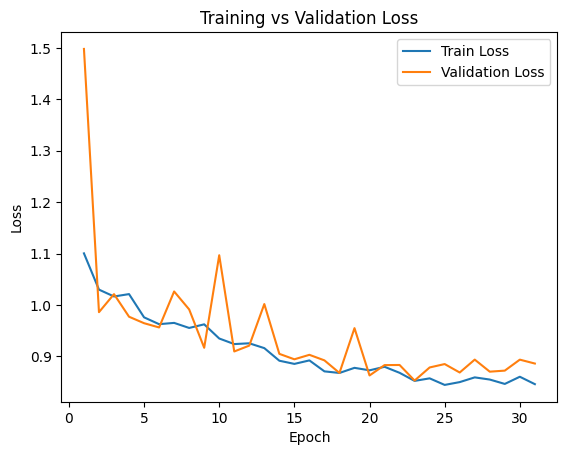

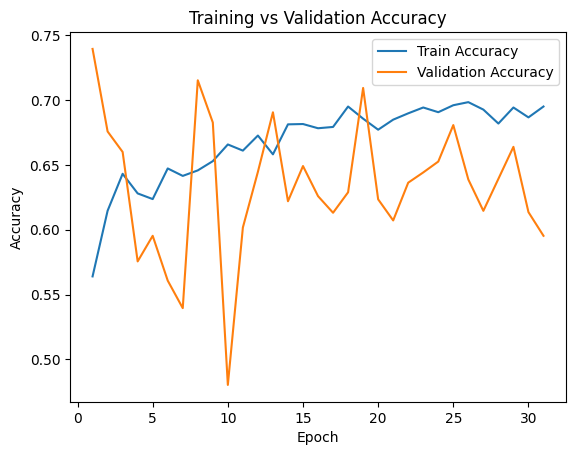

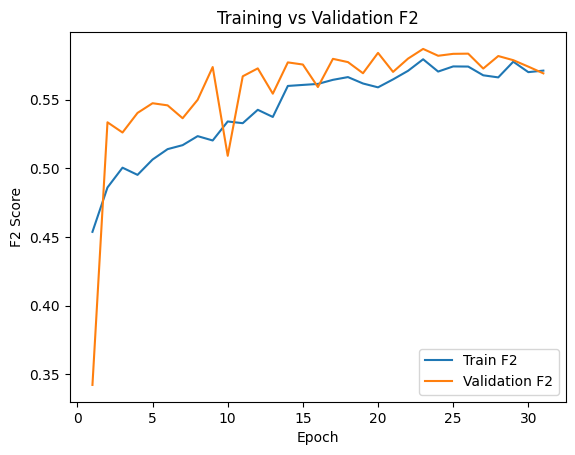

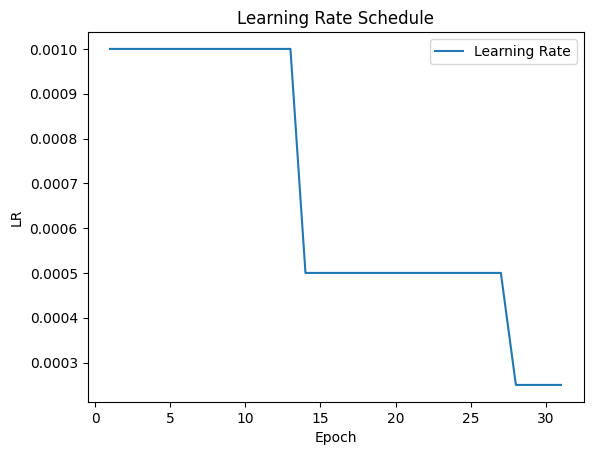

In [7]:
epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_f2s, label="Train F2")
plt.plot(epochs, val_f2s, label="Validation F2")
plt.xlabel("Epoch")
plt.ylabel("F2 Score")
plt.title("Training vs Validation F2")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, learning_rates, label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Learning Rate Schedule")
plt.legend()
plt.show()


This section sweeps thresholds on the validation set and keeps the threshold with the best F2 score.


In [8]:
model.eval()

val_labels = []
val_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)

        val_labels.extend(labels.numpy())
        val_probs.extend(probs.cpu().numpy())

thresholds = np.arange(0.05, 0.95, 0.05)
best_threshold = 0.5
best_f2 = -1

for threshold in thresholds:
    preds = [1 if p >= threshold else 0 for p in val_probs]
    f2 = fbeta_score(val_labels, preds, beta=2)

    print(
        f"Threshold={threshold:.2f} | "
        f"F2={f2:.4f} | "
        f"Precision={precision_score(val_labels, preds, zero_division=0):.4f} | "
        f"Recall={recall_score(val_labels, preds, zero_division=0):.4f} | "
        f"Balanced Acc={balanced_accuracy_score(val_labels, preds):.4f}"
    )

    if f2 > best_f2:
        best_f2 = f2
        best_threshold = threshold

print(f"Best threshold on validation set: {best_threshold:.2f}")


Threshold=0.05 | F2=0.5060 | Precision=0.1705 | Recall=0.9958 | Balanced Acc=0.6783
Threshold=0.10 | F2=0.5202 | Precision=0.1793 | Recall=0.9915 | Balanced Acc=0.6963
Threshold=0.15 | F2=0.5286 | Precision=0.1849 | Recall=0.9873 | Balanced Acc=0.7065
Threshold=0.20 | F2=0.5382 | Precision=0.1922 | Recall=0.9788 | Balanced Acc=0.7179
Threshold=0.25 | F2=0.5482 | Precision=0.1986 | Recall=0.9788 | Balanced Acc=0.7288
Threshold=0.30 | F2=0.5556 | Precision=0.2050 | Recall=0.9703 | Balanced Acc=0.7368
Threshold=0.35 | F2=0.5639 | Precision=0.2132 | Recall=0.9576 | Balanced Acc=0.7456
Threshold=0.40 | F2=0.5734 | Precision=0.2210 | Recall=0.9534 | Balanced Acc=0.7549
Threshold=0.45 | F2=0.5821 | Precision=0.2286 | Recall=0.9492 | Balanced Acc=0.7632
Threshold=0.50 | F2=0.5868 | Precision=0.2375 | Recall=0.9280 | Balanced Acc=0.7674
Threshold=0.55 | F2=0.5957 | Precision=0.2486 | Recall=0.9153 | Balanced Acc=0.7750
Threshold=0.60 | F2=0.5928 | Precision=0.2581 | Recall=0.8771 | Balanced Acc

Confusion Matrix:
[[775 565]
 [ 15 156]]

              precision    recall  f1-score   support

           0     0.9810    0.5784    0.7277      1340
           1     0.2164    0.9123    0.3498       171

    accuracy                         0.6161      1511
   macro avg     0.5987    0.7453    0.5387      1511
weighted avg     0.8945    0.6161    0.6849      1511



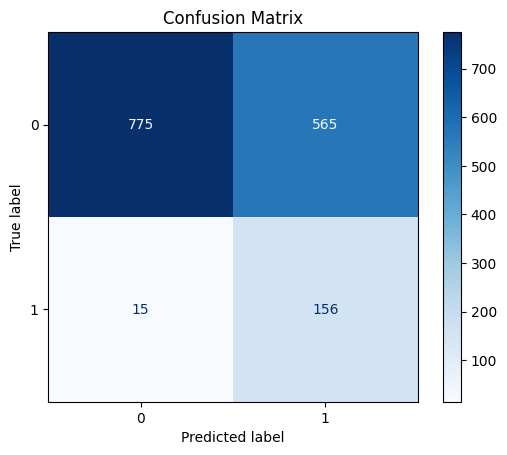

In [9]:
model = BatchNormGAPCNN().to(device)
model.load_state_dict(torch.load(model_save_path, map_location="cpu"))
model.to(device)
model.eval()

all_labels = []
all_probs = []
all_preds = []

threshold = best_threshold

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= threshold).long()

        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)
print()
print(classification_report(all_labels, all_preds, digits=4, zero_division=0))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


Collected 9 correct predictions and 9 wrong predictions.


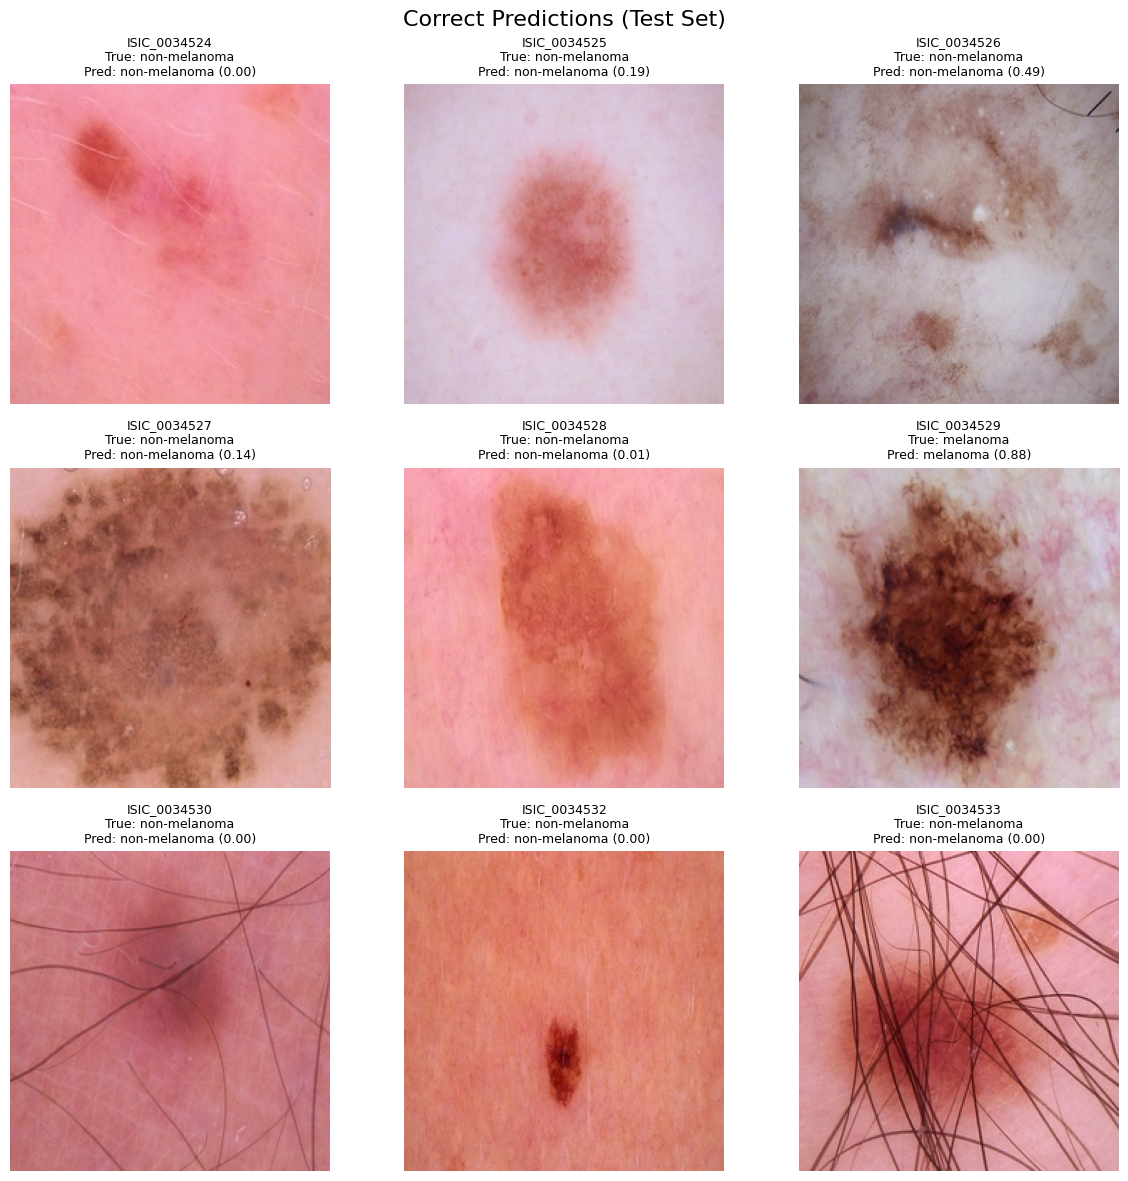

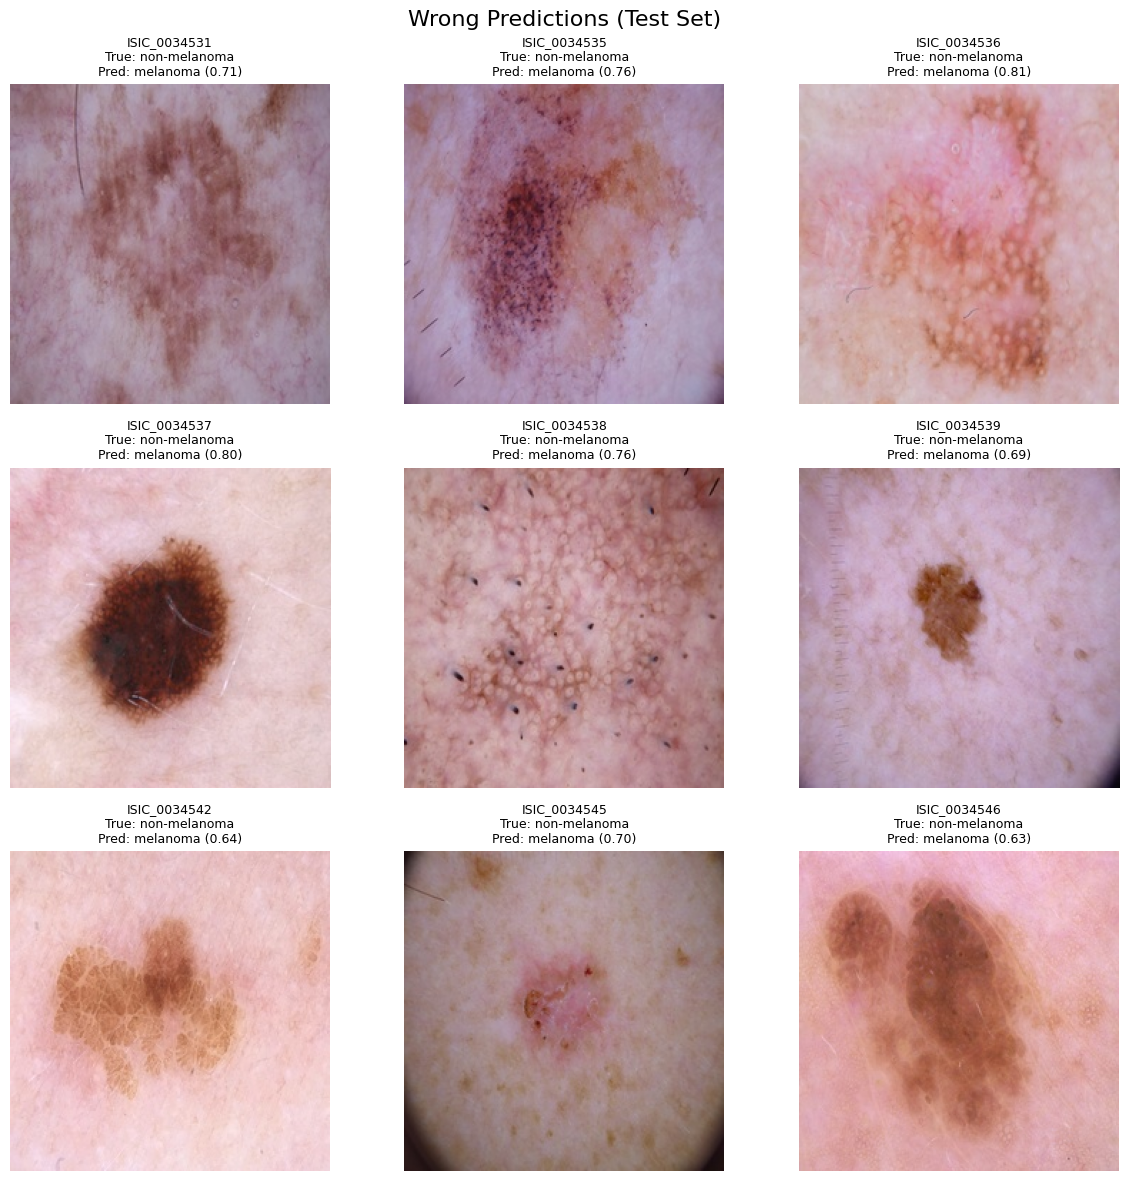

In [10]:
label_names = {0: "non-melanoma", 1: "melanoma"}
imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
imagenet_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize_image(image_tensor):
    image = image_tensor.detach().cpu() * imagenet_std + imagenet_mean
    image = image.permute(1, 2, 0).numpy()
    return np.clip(image, 0, 1)

correct_examples = []
wrong_examples = []
global_idx = 0

test_metadata = test_loader.dataset.data.reset_index(drop=True)

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs).squeeze(1).cpu()
        preds = (probs >= threshold).long()

        for i in range(len(labels)):
            example = {
                "image": images[i],
                "true_label": int(labels[i].item()),
                "pred_label": int(preds[i].item()),
                "probability": float(probs[i].item()),
                "image_id": test_metadata.iloc[global_idx]["image_id"],
            }

            if example["true_label"] == example["pred_label"]:
                if len(correct_examples) < 9:
                    correct_examples.append(example)
            else:
                if len(wrong_examples) < 9:
                    wrong_examples.append(example)

            global_idx += 1

        if len(correct_examples) >= 9 and len(wrong_examples) >= 9:
            break


def plot_examples(examples, title):
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()

    for ax, example in zip(axes, examples):
        ax.imshow(denormalize_image(example["image"]))
        ax.set_title(
            f"{example['image_id']}\n"
            f"True: {label_names[example['true_label']]}\n"
            f"Pred: {label_names[example['pred_label']]} ({example['probability']:.2f})",
            fontsize=9,
        )
        ax.axis("off")

    for ax in axes[len(examples):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

print(f"Collected {len(correct_examples)} correct predictions and {len(wrong_examples)} wrong predictions.")
plot_examples(correct_examples, "Correct Predictions (Test Set)")
plot_examples(wrong_examples, "Wrong Predictions (Test Set)")


- The augmented BatchNorm-GAP weighted CNN shows meaningful learning, with training F2 increasing over time and validation F2 peaking at 0.5868. 
- This indicates that the model is able to learn melanoma-sensitive features and is not strongly underfitting. 
- However, validation performance fluctuates after the mid-training stage, suggesting mild overfitting. 
- On the test set, the model achieves very high melanoma recall of 91.23%, missing only 15 melanoma cases, but this comes at the expense of 565 false positives, reducing precision to 21.64% and overall accuracy to 61.61%. 
- Therefore, the augmented model improves sensitivity substantially, but it does not improve overall classification balance and behaves mainly as a high-recall screening model rather than a well-balanced classifier.


| Model | Main Change | Accuracy | Melanoma Precision | Melanoma Recall | Melanoma F1 | Main Interpretation |
|---|---|---:|---:|---:|---:|---|
| `01.cnn_baseline` | Plain CNN with standard BCE loss | 0.8848 | 0.4848 | 0.2807 | 0.3556 | High overall accuracy, but poor melanoma detection due to class imbalance |
| `02.cnn_baseline_weighted` | Added `pos_weight` to BCE loss and tuned threshold by F1 | 0.8379 | 0.3706 | 0.6199 | 0.4639 | Best overall balance between melanoma detection and overall classification quality |
| `03.cnn_batchnorm_weighted` | Added BatchNorm to weighted CNN and tuned threshold by F2 | 0.7240 | 0.2560 | 0.7544 | 0.3822 | Higher recall, but much more aggressive and less balanced than `02` |
| `04.cnn_batchnorm_focalloss` | Replaced weighted BCE with focal loss and tuned threshold by F2 | 0.5850 | 0.2047 | 0.9240 | 0.3351 | Highest recall, but excessive false positives and weakest overall balance |
| `05.cnn_batchnorm_gap_augmented_weighted` | Added GAP head, stronger augmentation, weighted BCE, LR scheduling, and early stopping | 0.6161 | 0.2164 | 0.9123 | 0.3498 | Very high recall and fewer missed melanomas, but still too many false positives for a balanced model |
